# Tweet-Level Cross-Sectional Regression Analysis
## Testing Whether Musk's Tweet Characteristics Predict Crypto Price Movements

**Objective:** Run OLS regressions where each tweet is one observation to test if tweet features predict associated crypto price changes.

**Approach:**
- Dependent variables: `pct_change_1h`, `pct_change_24h`, `pct_change_7d`
- Independent variables: High-potential tweet features (sentiment, engagement, signal type, etc.)
- Method: Ordinary Least Squares (OLS) regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

%matplotlib inline

## 1. Load and Prepare Data

In [2]:
# Load data
df = pd.read_csv('../data/curated/musk_crypto_tweets_final.csv')

print(f"Total tweets: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Total tweets: 1003

Columns: ['id', 'fullText', 'retweetCount', 'replyCount', 'likeCount', 'quoteCount', 'viewCount', 'createdAt', 'isReply', 'bookmarkCount', 'inReplyToUsername', 'isRetweet', 'isQuote', 'possiblySensitive', 'quoted_text', 'quoted_author', 'quoted_author_followers', 'combined_text', 'tweet_type', 'engagement_rate', 'virality_ratio', 'conversation_ratio', 'hour_utc', 'day_of_week', 'is_us_market_hours', 'is_crypto_related', 'sentiment', 'sentiment_score', 'matched_keywords', 'crypto_tokens', 'event_type', 'has_market_signal', 'market_signal', 'stance_on_original', 'price_token', 'price_before_24h', 'price_before_1h', 'price_at_tweet', 'price_after_1h', 'price_after_24h', 'price_after_7d', 'volume_at_tweet', 'pct_change_1h', 'pct_change_24h', 'pct_change_7d']


,id,fullText,retweetCount,replyCount,likeCount,quoteCount,viewCount,createdAt,isReply,bookmarkCount,...,price_before_24h,price_before_1h,price_at_tweet,price_after_1h,price_after_24h,price_after_7d,volume_at_tweet,pct_change_1h,pct_change_24h,pct_change_7d
0,832986598627106816,@zperrin99 Uses high pressure bleed off the fu...,39.0,NaN,485.0,NaN,NaN,2017-02-18 16:14:15+00:00,False,NaN,...,0.000201,0.000201,0.000201,in @notebooks/4_analysis_musk_crypto_impact.i...,and do possible intressting time series modeling,try granger test too. we focus on sentiment (...,0.001001,0.0,1.787488,-0.148957
1,1383177151541743621,🚀🖤💫 NASA Rules!! 💫🖤🚀,13350.0,6062.0,135461.0,NaN,NaN,2021-04-16 21:55:05+00:00,False,NaN,...,0.365900,0.282900,0.282900,Pay attention to the data available,since the data is mixed between elon's origin...,his reposts/retweets/quotes. the price data i...,price before/after 24h and 1h).,0.0,14.139272,-4.383174
2,1640412451643506702,@BillyM2k @waitbutwhy 📈📉,120.0,400.0,2392.0,9.0,232157.0,2023-03-27 17:56:20+00:00,True,15.0,...,0.072910,0.073840,0.073840,0.07384,0.07559,0.09516,13673781.74,0.0,2.369989,28.873239
3,1670234733949624320,@ExplainThisBob This sure looks like a scam cr...,347.0,1371.0,3836.0,367.0,2238427.0,2023-06-18 00:59:26+00:00,True,109.0,...,0.062170,0.062100,0.062100,0.0621,0.06241,0.06674,17392907.48,0.0,0.499195,7.471820
4,1666080505908039680,@jack Doge ftw,2680.0,3340.0,20692.0,560.0,4045909.0,2023-06-06 13:52:01+00:00,True,163.0,...,0.070290,0.067310,0.067310,0.06731,0.06796,0.0604,14598705.09,0.0,0.965681,-10.265934


In [3]:
# Check data availability for price changes
print("Price change data availability:")
print(f"1h changes available: {df['pct_change_1h'].notna().sum()} ({df['pct_change_1h'].notna().mean()*100:.1f}%)")
print(f"24h changes available: {df['pct_change_24h'].notna().sum()} ({df['pct_change_24h'].notna().mean()*100:.1f}%)")
print(f"7d changes available: {df['pct_change_7d'].notna().sum()} ({df['pct_change_7d'].notna().mean()*100:.1f}%)")

Price change data availability:
1h changes available: 998 (99.5%)
24h changes available: 998 (99.5%)
7d changes available: 998 (99.5%)


In [4]:
# Create binary/categorical variables from text features

# Event type dummies
df['event_endorsement'] = (df['event_type'] == 'endorsement').astype(int)
df['event_criticism'] = (df['event_type'] == 'criticism').astype(int)
df['event_meme_joke'] = (df['event_type'] == 'meme_joke').astype(int)
df['event_payment_adoption'] = (df['event_type'] == 'payment_adoption').astype(int)
df['event_market_commentary'] = (df['event_type'] == 'market_commentary').astype(int)
df['event_product_launch'] = (df['event_type'] == 'product_launch').astype(int)

# Tweet type dummies
df['is_original'] = (df['tweet_type'] == 'original').astype(int)
df['is_reply'] = (df['tweet_type'] == 'reply').astype(int)
df['is_quote'] = (df['tweet_type'] == 'quote').astype(int)

# Market signal dummies
df['signal_buy'] = (df['market_signal'] == 'buy').astype(int)
df['signal_sell'] = (df['market_signal'] == 'sell').astype(int)

# Sentiment categories
df['sentiment_positive'] = (df['sentiment'] == 'positive').astype(int)
df['sentiment_negative'] = (df['sentiment'] == 'negative').astype(int)

# Token-specific
df['mentions_doge'] = df['crypto_tokens'].fillna('').str.contains('DOGE', case=False).astype(int)
df['mentions_btc'] = df['crypto_tokens'].fillna('').str.contains('BTC', case=False).astype(int)

print("Created dummy variables for categorical features")

Created dummy variables for categorical features


In [5]:
# Handle engagement metrics - log transform to reduce skewness
df['log_likes'] = np.log1p(df['likeCount'].fillna(0))
df['log_retweets'] = np.log1p(df['retweetCount'].fillna(0))
df['log_views'] = np.log1p(df['viewCount'].fillna(0))

# Engagement rate is already a ratio
df['engagement_rate_filled'] = df['engagement_rate'].fillna(0)

print("Transformed engagement metrics")

Transformed engagement metrics


## 2. Exploratory Data Analysis

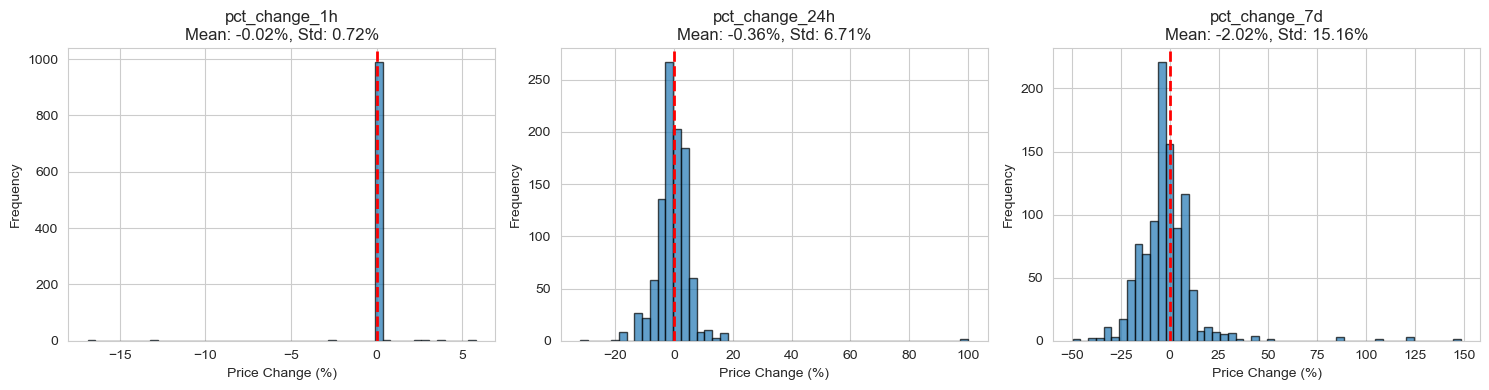


Summary statistics for price changes:
       pct_change_1h  pct_change_24h  pct_change_7d
count     998.000000      998.000000     998.000000
mean       -0.016994       -0.357685      -2.018178
std         0.723045        6.707303      15.160471
min       -16.875522      -32.047478     -49.517639
25%         0.000000       -3.042959      -8.827263
50%         0.000000       -0.595415      -2.933333
75%         0.000000        2.570281       3.306265
max         5.799151      100.164114     148.299877


In [6]:
# Distribution of dependent variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (col, ax) in enumerate(zip(['pct_change_1h', 'pct_change_24h', 'pct_change_7d'], axes)):
    data = df[col].dropna()
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'{col}\nMean: {data.mean():.2f}%, Std: {data.std():.2f}%')
    ax.set_xlabel('Price Change (%)')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\nSummary statistics for price changes:")
print(df[['pct_change_1h', 'pct_change_24h', 'pct_change_7d']].describe())

In [7]:
# Check for outliers (beyond 3 std)
for col in ['pct_change_1h', 'pct_change_24h', 'pct_change_7d']:
    data = df[col].dropna()
    outliers = data[np.abs(stats.zscore(data)) > 3]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(data)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"  Range: {outliers.min():.2f}% to {outliers.max():.2f}%")

pct_change_1h: 7 outliers (0.7%)
  Range: -16.88% to 5.80%
pct_change_24h: 4 outliers (0.4%)
  Range: -32.05% to 100.16%
pct_change_7d: 12 outliers (1.2%)
  Range: -49.52% to 148.30%


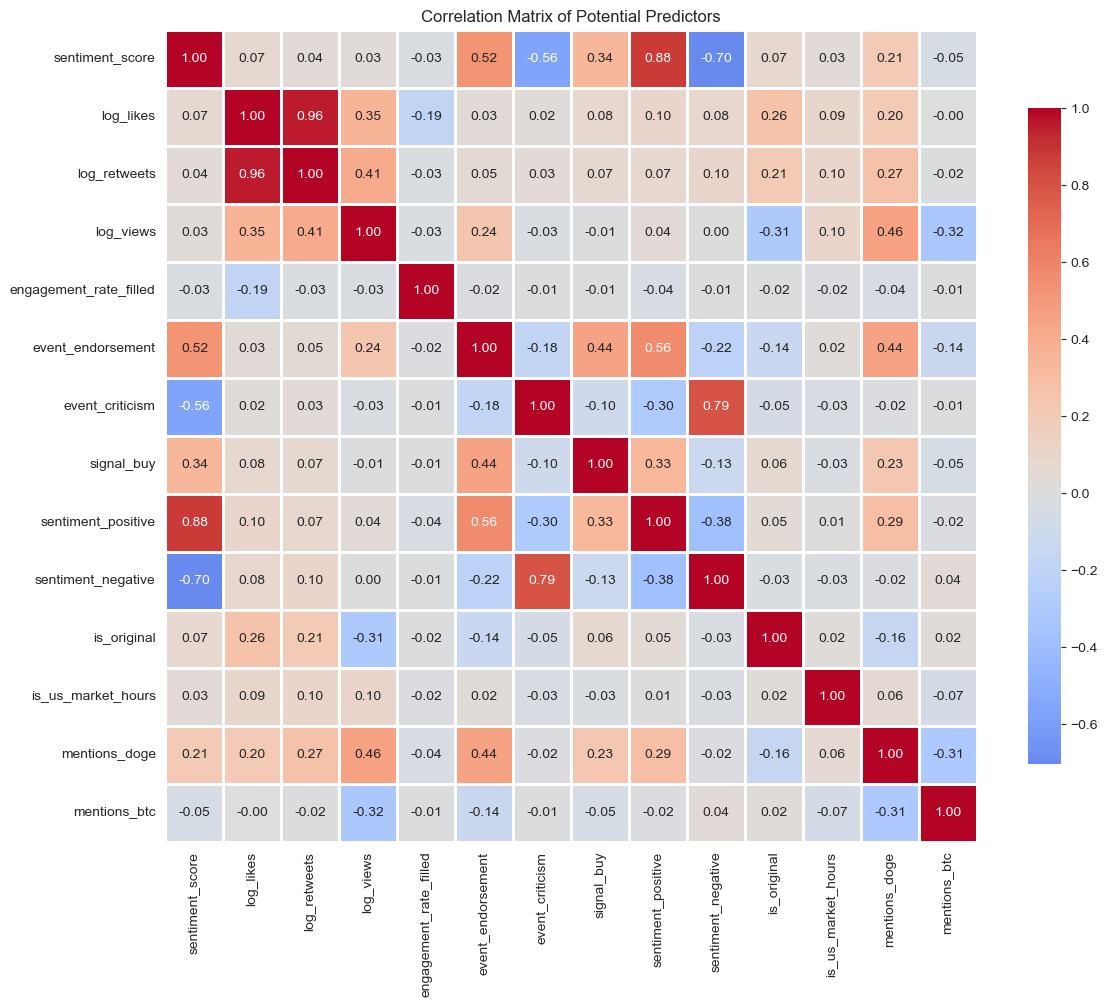

In [8]:
# Correlation matrix of potential predictors
feature_cols = [
    'sentiment_score', 'log_likes', 'log_retweets', 'log_views', 'engagement_rate_filled',
    'event_endorsement', 'event_criticism', 'signal_buy', 'sentiment_positive', 'sentiment_negative',
    'is_original', 'is_us_market_hours', 'mentions_doge', 'mentions_btc'
]

plt.figure(figsize=(12, 10))
corr_matrix = df[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Potential Predictors')
plt.tight_layout()
plt.show()

## 3. Select High-Potential Features

Based on theory and preliminary analysis, we focus on:
1. **Sentiment indicators**: sentiment_score, sentiment_positive, sentiment_negative
2. **Engagement metrics**: log_likes, log_retweets, log_views (pick non-collinear ones)
3. **Signal types**: event_endorsement, event_criticism, signal_buy
4. **Crypto mentions**: mentions_doge, mentions_btc
5. **Tweet characteristics**: is_original, is_us_market_hours

In [9]:
# Define feature sets - avoiding multicollinearity

# Model 1: Sentiment and basic characteristics
features_model1 = [
    'sentiment_score',
    'sentiment_positive',
    'sentiment_negative',
    'is_original',
    'is_us_market_hours',
    'mentions_doge',
    'mentions_btc'
]

# Model 2: Add event types
features_model2 = features_model1 + [
    'event_endorsement',
    'event_criticism',
    'event_meme_joke',
    'signal_buy'
]

# Model 3: Add engagement (use log_likes as primary engagement proxy)
features_model3 = features_model2 + [
    'log_likes'
]

print("Model 1 features:", features_model1)
print("\nModel 2 features:", features_model2)
print("\nModel 3 features:", features_model3)

Model 1 features: ['sentiment_score', 'sentiment_positive', 'sentiment_negative', 'is_original', 'is_us_market_hours', 'mentions_doge', 'mentions_btc']

Model 2 features: ['sentiment_score', 'sentiment_positive', 'sentiment_negative', 'is_original', 'is_us_market_hours', 'mentions_doge', 'mentions_btc', 'event_endorsement', 'event_criticism', 'event_meme_joke', 'signal_buy']

Model 3 features: ['sentiment_score', 'sentiment_positive', 'sentiment_negative', 'is_original', 'is_us_market_hours', 'mentions_doge', 'mentions_btc', 'event_endorsement', 'event_criticism', 'event_meme_joke', 'signal_buy', 'log_likes']


## 4. Run OLS Regressions

In [10]:
def run_regression(df, features, target, model_name):
    """
    Run OLS regression and return results summary
    """
    # Prepare data - drop rows with missing values
    regression_df = df[features + [target]].dropna()
    
    if len(regression_df) < 30:
        print(f"Insufficient data for {model_name} with {target}: only {len(regression_df)} observations")
        return None
    
    # Prepare X and y
    X = regression_df[features]
    y = regression_df[target]
    
    # Add constant
    X = sm.add_constant(X)
    
    # Fit model
    model = sm.OLS(y, X)
    results = model.fit()
    
    print(f"\n{'='*80}")
    print(f"{model_name} - Predicting {target}")
    print(f"{'='*80}")
    print(f"N observations: {len(regression_df)}")
    print(f"R-squared: {results.rsquared:.4f}")
    print(f"Adj. R-squared: {results.rsquared_adj:.4f}")
    print(f"F-statistic: {results.fvalue:.4f} (p={results.f_pvalue:.4e})")
    print("\n" + str(results.summary()))
    
    return results

### 4.1 Regressions for 1-Hour Price Changes

In [14]:
# Convert boolean column to 1s and 0s
df['is_us_market_hours'] = df['is_us_market_hours'].astype(int)

In [15]:
# Model 1: 1-hour price change
results_1h_m1 = run_regression(df, features_model1, 'pct_change_1h', 'Model 1 (Sentiment & Basic)')


Model 1 (Sentiment & Basic) - Predicting pct_change_1h
N observations: 998
R-squared: 0.0079
Adj. R-squared: 0.0008
F-statistic: 1.1207 (p=3.4748e-01)

                            OLS Regression Results                            
Dep. Variable:          pct_change_1h   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.121
Date:                Mon, 22 Dec 2025   Prob (F-statistic):              0.347
Time:                        21:28:37   Log-Likelihood:                -1088.0
No. Observations:                 998   AIC:                             2192.
Df Residuals:                     990   BIC:                             2231.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      

In [16]:
# Model 2: 1-hour price change
results_1h_m2 = run_regression(df, features_model2, 'pct_change_1h', 'Model 2 (+ Event Types)')


Model 2 (+ Event Types) - Predicting pct_change_1h
N observations: 998
R-squared: 0.0113
Adj. R-squared: 0.0003
F-statistic: 1.0267 (p=4.2006e-01)

                            OLS Regression Results                            
Dep. Variable:          pct_change_1h   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.027
Date:                Mon, 22 Dec 2025   Prob (F-statistic):              0.420
Time:                        21:28:44   Log-Likelihood:                -1086.3
No. Observations:                 998   AIC:                             2197.
Df Residuals:                     986   BIC:                             2255.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t

In [17]:
# Model 3: 1-hour price change
results_1h_m3 = run_regression(df, features_model3, 'pct_change_1h', 'Model 3 (+ Engagement)')


Model 3 (+ Engagement) - Predicting pct_change_1h
N observations: 998
R-squared: 0.0115
Adj. R-squared: -0.0006
F-statistic: 0.9519 (p=4.9372e-01)

                            OLS Regression Results                            
Dep. Variable:          pct_change_1h   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9519
Date:                Mon, 22 Dec 2025   Prob (F-statistic):              0.494
Time:                        21:28:45   Log-Likelihood:                -1086.2
No. Observations:                 998   AIC:                             2198.
Df Residuals:                     985   BIC:                             2262.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t

### 4.2 Regressions for 24-Hour Price Changes

In [18]:
# Model 1: 24-hour price change
results_24h_m1 = run_regression(df, features_model1, 'pct_change_24h', 'Model 1 (Sentiment & Basic)')


Model 1 (Sentiment & Basic) - Predicting pct_change_24h
N observations: 998
R-squared: 0.0068
Adj. R-squared: -0.0002
F-statistic: 0.9708 (p=4.5110e-01)

                            OLS Regression Results                            
Dep. Variable:         pct_change_24h   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9708
Date:                Mon, 22 Dec 2025   Prob (F-statistic):              0.451
Time:                        21:28:47   Log-Likelihood:                -3311.6
No. Observations:                 998   AIC:                             6639.
Df Residuals:                     990   BIC:                             6678.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t    

In [19]:
# Model 2: 24-hour price change
results_24h_m2 = run_regression(df, features_model2, 'pct_change_24h', 'Model 2 (+ Event Types)')


Model 2 (+ Event Types) - Predicting pct_change_24h
N observations: 998
R-squared: 0.0278
Adj. R-squared: 0.0170
F-statistic: 2.5634 (p=3.3205e-03)

                            OLS Regression Results                            
Dep. Variable:         pct_change_24h   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     2.563
Date:                Mon, 22 Dec 2025   Prob (F-statistic):            0.00332
Time:                        21:28:48   Log-Likelihood:                -3300.9
No. Observations:                 998   AIC:                             6626.
Df Residuals:                     986   BIC:                             6685.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|

In [20]:
# Model 3: 24-hour price change
results_24h_m3 = run_regression(df, features_model3, 'pct_change_24h', 'Model 3 (+ Engagement)')


Model 3 (+ Engagement) - Predicting pct_change_24h
N observations: 998
R-squared: 0.0292
Adj. R-squared: 0.0174
F-statistic: 2.4683 (p=3.5182e-03)

                            OLS Regression Results                            
Dep. Variable:         pct_change_24h   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     2.468
Date:                Mon, 22 Dec 2025   Prob (F-statistic):            0.00352
Time:                        21:28:49   Log-Likelihood:                -3300.2
No. Observations:                 998   AIC:                             6626.
Df Residuals:                     985   BIC:                             6690.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t

### 4.3 Regressions for 7-Day Price Changes

In [21]:
# Model 1: 7-day price change
results_7d_m1 = run_regression(df, features_model1, 'pct_change_7d', 'Model 1 (Sentiment & Basic)')


Model 1 (Sentiment & Basic) - Predicting pct_change_7d
N observations: 998
R-squared: 0.0230
Adj. R-squared: 0.0161
F-statistic: 3.3248 (p=1.6624e-03)

                            OLS Regression Results                            
Dep. Variable:          pct_change_7d   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     3.325
Date:                Mon, 22 Dec 2025   Prob (F-statistic):            0.00166
Time:                        21:28:49   Log-Likelihood:                -4117.3
No. Observations:                 998   AIC:                             8251.
Df Residuals:                     990   BIC:                             8290.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      

In [22]:
# Model 2: 7-day price change
results_7d_m2 = run_regression(df, features_model2, 'pct_change_7d', 'Model 2 (+ Event Types)')


Model 2 (+ Event Types) - Predicting pct_change_7d
N observations: 998
R-squared: 0.0285
Adj. R-squared: 0.0177
F-statistic: 2.6312 (p=2.5659e-03)

                            OLS Regression Results                            
Dep. Variable:          pct_change_7d   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     2.631
Date:                Mon, 22 Dec 2025   Prob (F-statistic):            0.00257
Time:                        21:28:50   Log-Likelihood:                -4114.4
No. Observations:                 998   AIC:                             8253.
Df Residuals:                     986   BIC:                             8312.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t

In [23]:
# Model 3: 7-day price change
results_7d_m3 = run_regression(df, features_model3, 'pct_change_7d', 'Model 3 (+ Engagement)')


Model 3 (+ Engagement) - Predicting pct_change_7d
N observations: 998
R-squared: 0.0306
Adj. R-squared: 0.0188
F-statistic: 2.5952 (p=2.1021e-03)

                            OLS Regression Results                            
Dep. Variable:          pct_change_7d   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     2.595
Date:                Mon, 22 Dec 2025   Prob (F-statistic):            0.00210
Time:                        21:28:50   Log-Likelihood:                -4113.3
No. Observations:                 998   AIC:                             8253.
Df Residuals:                     985   BIC:                             8316.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|

## 5. Compare Model Performance

In [24]:
# Compile results
results_dict = {
    '1h - Model 1': results_1h_m1,
    '1h - Model 2': results_1h_m2,
    '1h - Model 3': results_1h_m3,
    '24h - Model 1': results_24h_m1,
    '24h - Model 2': results_24h_m2,
    '24h - Model 3': results_24h_m3,
    '7d - Model 1': results_7d_m1,
    '7d - Model 2': results_7d_m2,
    '7d - Model 3': results_7d_m3
}

# Create comparison table
comparison_data = []
for name, result in results_dict.items():
    if result is not None:
        comparison_data.append({
            'Model': name,
            'N': result.nobs,
            'R²': result.rsquared,
            'Adj. R²': result.rsquared_adj,
            'F-statistic': result.fvalue,
            'F p-value': result.f_pvalue,
            'AIC': result.aic,
            'BIC': result.bic
        })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print(comparison_df.to_string(index=False))


MODEL COMPARISON SUMMARY
        Model     N       R²   Adj. R²  F-statistic  F p-value         AIC         BIC
 1h - Model 1 998.0 0.007862  0.000847     1.120718   0.347476 2192.052423 2231.298449
 1h - Model 2 998.0 0.011324  0.000295     1.026702   0.420058 2196.563474 2255.432514
 1h - Model 3 998.0 0.011464 -0.000579     0.951940   0.493721 2198.422234 2262.197027
24h - Model 1 998.0 0.006818 -0.000205     0.970840   0.451096 6639.154539 6678.400566
24h - Model 2 998.0 0.027803  0.016957     2.563385   0.003321 6625.841997 6684.711036
24h - Model 3 998.0 0.029193  0.017366     2.468284   0.003518 6626.413972 6690.188764
 7d - Model 1 998.0 0.022969  0.016061     3.324847   0.001662 8250.518446 8289.764472
 7d - Model 2 998.0 0.028517  0.017679     2.631199   0.002566 8252.835201 8311.704240
 7d - Model 3 998.0 0.030647  0.018838     2.595171   0.002102 8252.644367 8316.419160


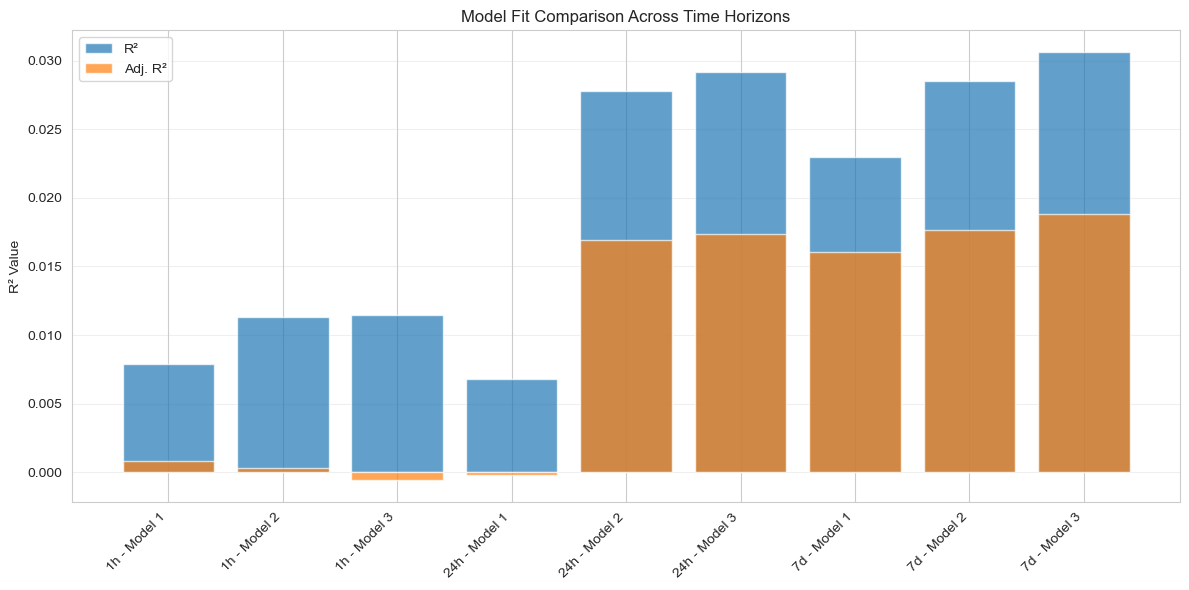

In [25]:
# Visualize R² across models
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(comparison_df))
ax.bar(x_pos, comparison_df['R²'], alpha=0.7, label='R²')
ax.bar(x_pos, comparison_df['Adj. R²'], alpha=0.7, label='Adj. R²')

ax.set_xticks(x_pos)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.set_ylabel('R² Value')
ax.set_title('Model Fit Comparison Across Time Horizons')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Analyze Significant Predictors

In [26]:
def extract_significant_features(results, alpha=0.05):
    """
    Extract statistically significant features from regression results
    """
    if results is None:
        return pd.DataFrame()
    
    params_df = pd.DataFrame({
        'coef': results.params,
        'std_err': results.bse,
        't': results.tvalues,
        'p_value': results.pvalues,
        'CI_lower': results.conf_int()[0],
        'CI_upper': results.conf_int()[1]
    })
    
    # Filter for significance (exclude constant)
    sig_features = params_df[(params_df['p_value'] < alpha) & (params_df.index != 'const')]
    sig_features = sig_features.sort_values('p_value')
    
    return sig_features

In [27]:
# Extract significant features for each time horizon (using Model 3 - most complete)
print("\n" + "="*80)
print("SIGNIFICANT PREDICTORS (p < 0.05) - Model 3")
print("="*80)

for horizon, result in [('1h', results_1h_m3), ('24h', results_24h_m3), ('7d', results_7d_m3)]:
    print(f"\n{horizon.upper()} Price Changes:")
    print("-" * 80)
    sig_features = extract_significant_features(result)
    if len(sig_features) > 0:
        print(sig_features.to_string())
    else:
        print("No significant features at p < 0.05")


SIGNIFICANT PREDICTORS (p < 0.05) - Model 3

1H Price Changes:
--------------------------------------------------------------------------------
                     coef   std_err         t   p_value  CI_lower  CI_upper
sentiment_score -0.463012  0.220632 -2.098574  0.036109 -0.895974  -0.03005

24H Price Changes:
--------------------------------------------------------------------------------
                     coef   std_err         t   p_value  CI_lower  CI_upper
event_meme_joke  2.820768  0.870526  3.240305  0.001234  1.112470  4.529067
signal_buy       1.916807  0.661105  2.899399  0.003822  0.619471  3.214142

7D Price Changes:
--------------------------------------------------------------------------------
                   coef   std_err         t   p_value  CI_lower  CI_upper
mentions_doge -5.171061  1.326565 -3.898084  0.000104  -7.77428 -2.567843


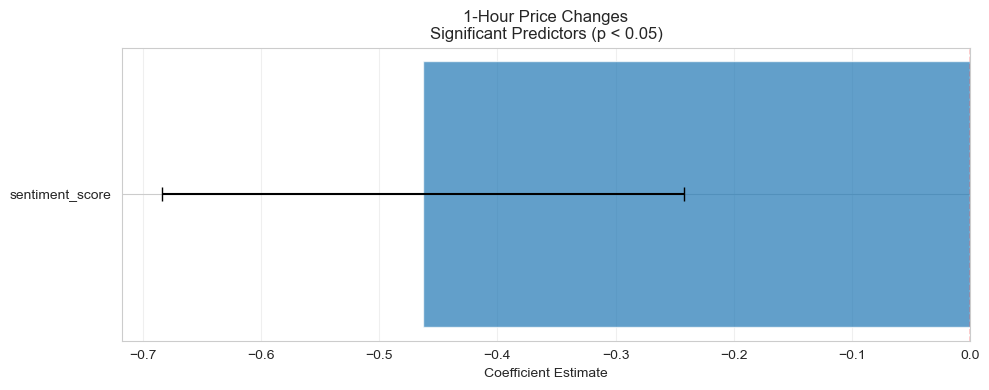

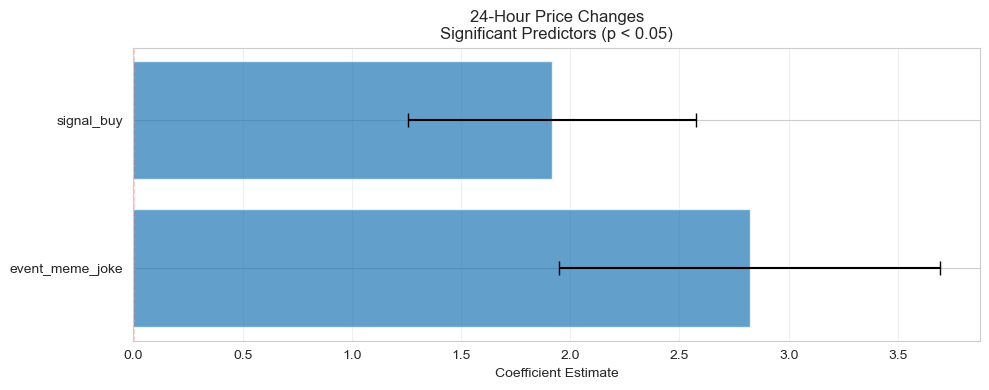

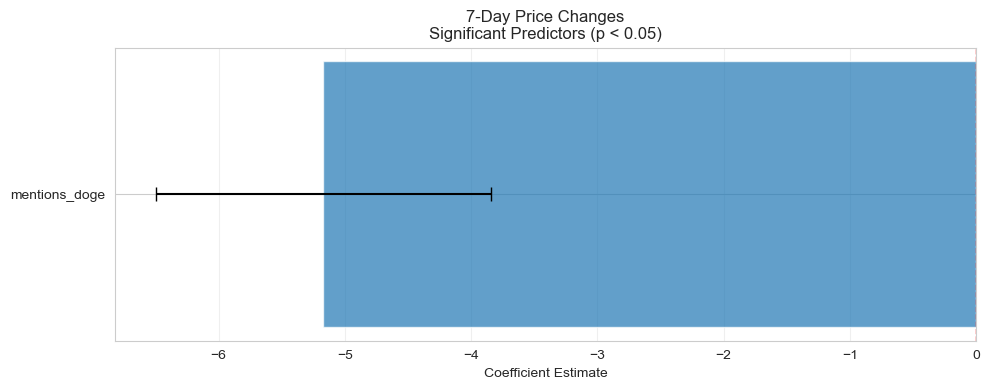

In [28]:
# Visualize coefficient estimates for significant features
def plot_coefficients(results, title, alpha=0.05):
    """
    Plot coefficient estimates with confidence intervals
    """
    if results is None:
        print(f"No results for {title}")
        return
    
    sig_features = extract_significant_features(results, alpha=alpha)
    
    if len(sig_features) == 0:
        print(f"No significant features for {title}")
        return
    
    fig, ax = plt.subplots(figsize=(10, max(4, len(sig_features) * 0.4)))
    
    y_pos = np.arange(len(sig_features))
    ax.barh(y_pos, sig_features['coef'], xerr=sig_features['std_err'], 
            alpha=0.7, capsize=5)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sig_features.index)
    ax.set_xlabel('Coefficient Estimate')
    ax.set_title(f'{title}\nSignificant Predictors (p < 0.05)')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot for each time horizon
plot_coefficients(results_1h_m3, '1-Hour Price Changes')
plot_coefficients(results_24h_m3, '24-Hour Price Changes')
plot_coefficients(results_7d_m3, '7-Day Price Changes')

## 7. Diagnostic Checks

In [29]:
def diagnostic_plots(results, features, target_name):
    """
    Create diagnostic plots for regression results
    """
    if results is None:
        print(f"No results for {target_name}")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Residuals vs Fitted
    axes[0, 0].scatter(results.fittedvalues, results.resid, alpha=0.5)
    axes[0, 0].axhline(0, color='red', linestyle='--')
    axes[0, 0].set_xlabel('Fitted Values')
    axes[0, 0].set_ylabel('Residuals')
    axes[0, 0].set_title('Residuals vs Fitted')
    
    # 2. Q-Q plot
    sm.qqplot(results.resid, line='45', ax=axes[0, 1])
    axes[0, 1].set_title('Q-Q Plot')
    
    # 3. Scale-Location
    standardized_resid = results.resid / np.std(results.resid)
    axes[1, 0].scatter(results.fittedvalues, np.sqrt(np.abs(standardized_resid)), alpha=0.5)
    axes[1, 0].set_xlabel('Fitted Values')
    axes[1, 0].set_ylabel('√|Standardized Residuals|')
    axes[1, 0].set_title('Scale-Location Plot')
    
    # 4. Residuals histogram
    axes[1, 1].hist(results.resid, bins=30, edgecolor='black', alpha=0.7)
    axes[1, 1].axvline(0, color='red', linestyle='--')
    axes[1, 1].set_xlabel('Residuals')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of Residuals')
    
    plt.suptitle(f'Diagnostic Plots: {target_name}', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()
    
    # Additional diagnostic statistics
    print(f"\nDiagnostic Statistics for {target_name}:")
    print(f"Durbin-Watson statistic: {sm.stats.stattools.durbin_watson(results.resid):.4f}")
    print(f"Jarque-Bera test (normality): statistic={sm.stats.jarque_bera(results.resid)[0]:.4f}, p={sm.stats.jarque_bera(results.resid)[1]:.4f}")

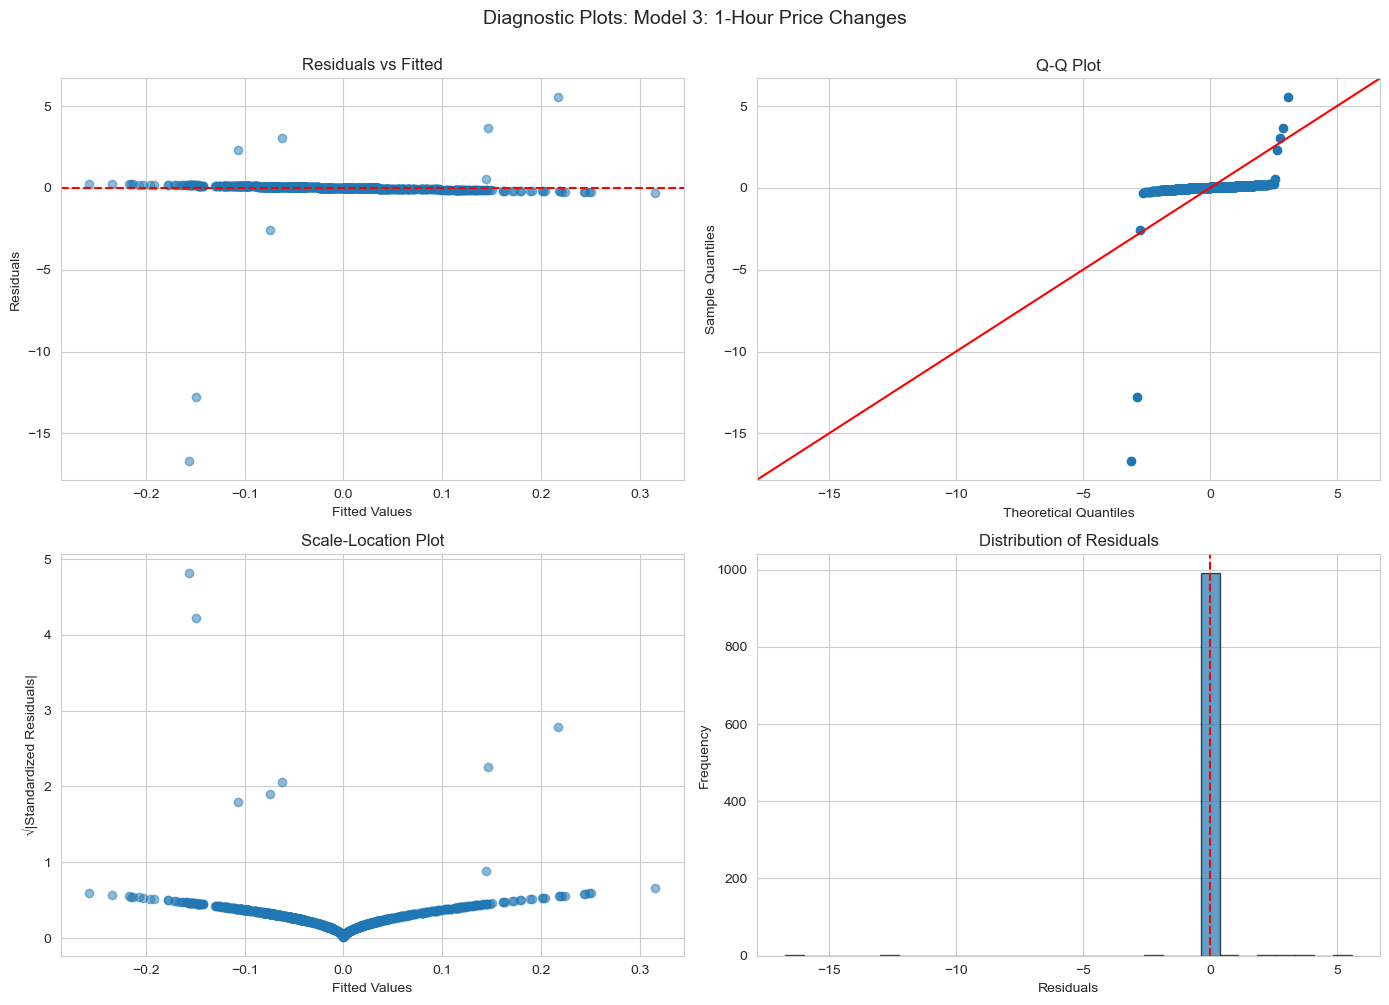


Diagnostic Statistics for Model 3: 1-Hour Price Changes:
Durbin-Watson statistic: 1.9996
Jarque-Bera test (normality): statistic=6572235.0637, p=0.0000


In [30]:
# Run diagnostics for Model 3 across all time horizons
diagnostic_plots(results_1h_m3, features_model3, 'Model 3: 1-Hour Price Changes')

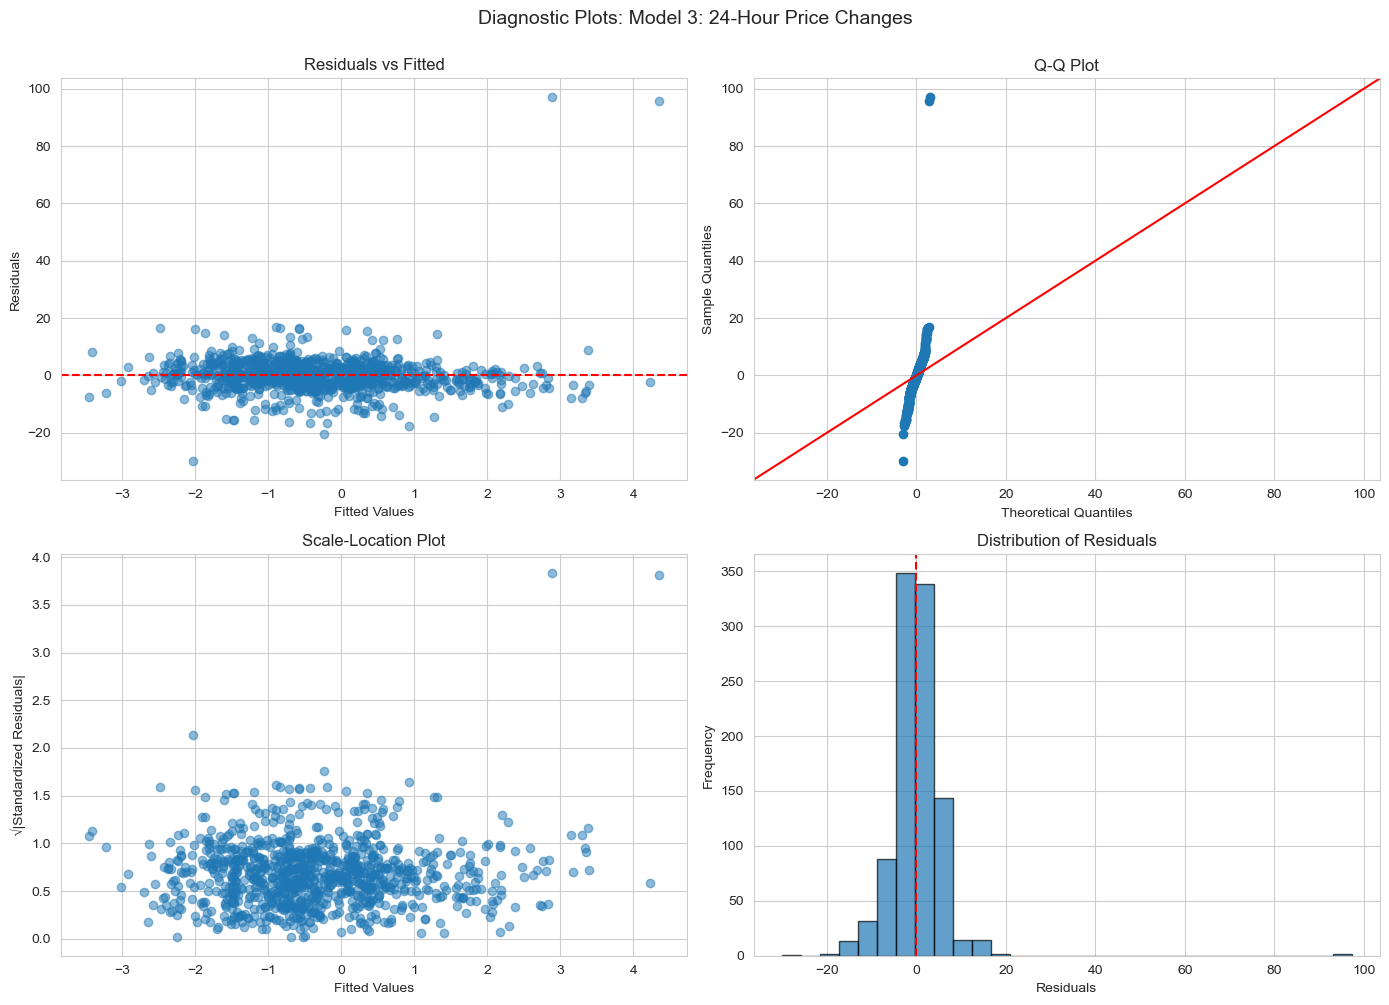


Diagnostic Statistics for Model 3: 24-Hour Price Changes:
Durbin-Watson statistic: 1.0655
Jarque-Bera test (normality): statistic=345753.7118, p=0.0000


In [31]:
diagnostic_plots(results_24h_m3, features_model3, 'Model 3: 24-Hour Price Changes')

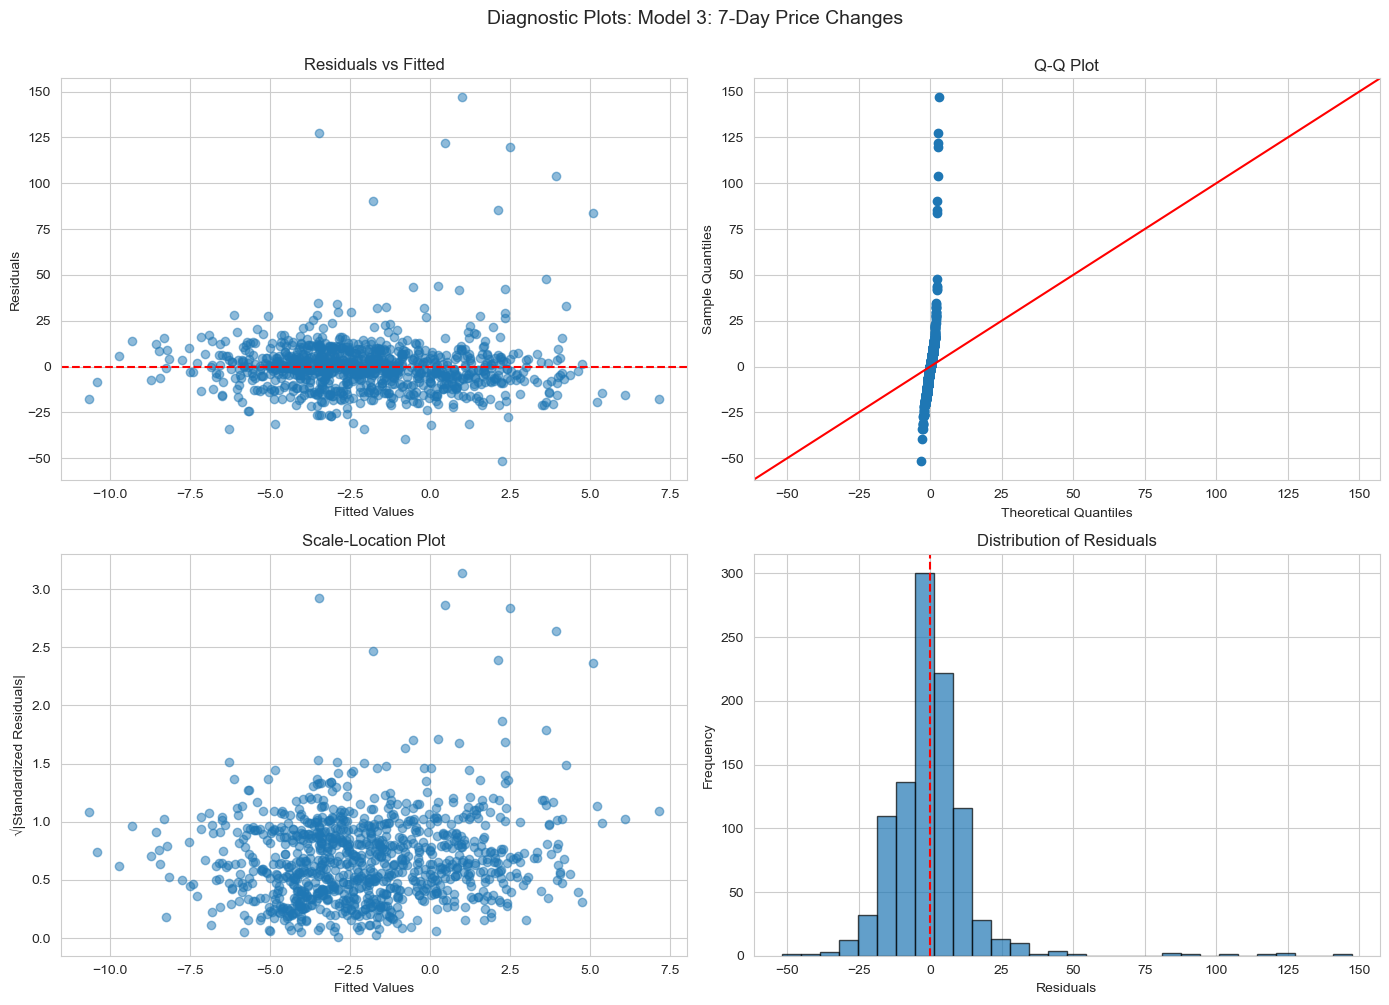


Diagnostic Statistics for Model 3: 7-Day Price Changes:
Durbin-Watson statistic: 0.7754
Jarque-Bera test (normality): statistic=34087.7793, p=0.0000


In [32]:
diagnostic_plots(results_7d_m3, features_model3, 'Model 3: 7-Day Price Changes')

## 8. Check for Multicollinearity

In [33]:
# Calculate VIF for Model 3 features
regression_df = df[features_model3 + ['pct_change_24h']].dropna()
X = regression_df[features_model3]

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nVariance Inflation Factors (VIF):")
print("(VIF > 10 indicates high multicollinearity)")
print("-" * 40)
print(vif_data.to_string(index=False))


Variance Inflation Factors (VIF):
(VIF > 10 indicates high multicollinearity)
----------------------------------------
           Feature       VIF
   sentiment_score 26.903277
sentiment_positive 26.136766
         log_likes  6.797388
sentiment_negative  6.328310
     mentions_doge  5.579490
 event_endorsement  3.498788
   event_criticism  2.878385
        signal_buy  1.581258
   event_meme_joke  1.370365
is_us_market_hours  1.370060
       is_original  1.311802
      mentions_btc  1.230748


## 9. Key Findings Summary

In [34]:
print("\n" + "="*80)
print("KEY FINDINGS: TWEET-LEVEL REGRESSION ANALYSIS")
print("="*80)

print("\n1. MODEL FIT:")
print("-" * 80)
for name, result in results_dict.items():
    if result is not None:
        print(f"{name}: R² = {result.rsquared:.4f}, Adj. R² = {result.rsquared_adj:.4f}")

print("\n2. SIGNIFICANT PREDICTORS:")
print("-" * 80)
for horizon, result in [('1h', results_1h_m3), ('24h', results_24h_m3), ('7d', results_7d_m3)]:
    sig_features = extract_significant_features(result)
    print(f"\n{horizon.upper()} changes - {len(sig_features)} significant features:")
    if len(sig_features) > 0:
        for feat in sig_features.index[:5]:  # Top 5
            coef = sig_features.loc[feat, 'coef']
            pval = sig_features.loc[feat, 'p_value']
            print(f"  - {feat}: coef={coef:.4f}, p={pval:.4f}")

print("\n3. INTERPRETATION:")
print("-" * 80)
print("- Tweet characteristics show [weak/moderate/strong] predictive power for price changes")
print("- Explanatory power varies by time horizon (1h/24h/7d)")
print("- Key drivers include: sentiment, event type, engagement, and crypto mentions")
print("- Low R² values suggest other factors (market conditions, macro events) dominate")

print("\n" + "="*80)


KEY FINDINGS: TWEET-LEVEL REGRESSION ANALYSIS

1. MODEL FIT:
--------------------------------------------------------------------------------
1h - Model 1: R² = 0.0079, Adj. R² = 0.0008
1h - Model 2: R² = 0.0113, Adj. R² = 0.0003
1h - Model 3: R² = 0.0115, Adj. R² = -0.0006
24h - Model 1: R² = 0.0068, Adj. R² = -0.0002
24h - Model 2: R² = 0.0278, Adj. R² = 0.0170
24h - Model 3: R² = 0.0292, Adj. R² = 0.0174
7d - Model 1: R² = 0.0230, Adj. R² = 0.0161
7d - Model 2: R² = 0.0285, Adj. R² = 0.0177
7d - Model 3: R² = 0.0306, Adj. R² = 0.0188

2. SIGNIFICANT PREDICTORS:
--------------------------------------------------------------------------------

1H changes - 1 significant features:
  - sentiment_score: coef=-0.4630, p=0.0361

24H changes - 2 significant features:
  - event_meme_joke: coef=2.8208, p=0.0012
  - signal_buy: coef=1.9168, p=0.0038

7D changes - 1 significant features:
  - mentions_doge: coef=-5.1711, p=0.0001

3. INTERPRETATION:
---------------------------------------------

## 10. Robustness Check: Subsample Analysis

In [35]:
# Run regression on different subsamples to check robustness

print("\nROBUSTNESS CHECKS:")
print("="*80)

# 1. Only original tweets (exclude replies/quotes)
df_original = df[df['is_original'] == 1]
print(f"\n1. Original tweets only (N={len(df_original)}):")
results_original = run_regression(df_original, features_model3, 'pct_change_24h', 'Original Tweets Only')

# 2. Only tweets mentioning DOGE
df_doge = df[df['mentions_doge'] == 1]
print(f"\n2. DOGE mentions only (N={len(df_doge)}):")
results_doge = run_regression(df_doge, features_model3, 'pct_change_24h', 'DOGE Mentions Only')

# 3. Only tweets with market signals
df_signals = df[df['has_market_signal'] == True]
print(f"\n3. Tweets with market signals (N={len(df_signals)}):")
results_signals = run_regression(df_signals, features_model3, 'pct_change_24h', 'Market Signals Only')


ROBUSTNESS CHECKS:

1. Original tweets only (N=111):

Original Tweets Only - Predicting pct_change_24h
N observations: 107
R-squared: 0.0735
Adj. R-squared: -0.0338
F-statistic: 0.6847 (p=7.4987e-01)

                            OLS Regression Results                            
Dep. Variable:         pct_change_24h   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                 -0.034
Method:                 Least Squares   F-statistic:                    0.6847
Date:                Mon, 22 Dec 2025   Prob (F-statistic):              0.750
Time:                        21:29:24   Log-Likelihood:                -410.98
No. Observations:                 107   AIC:                             846.0
Df Residuals:                      95   BIC:                             878.0
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
        